# Model Training

## Import Data and Required Packages

### Importing Pandas, Numpy, Matplotlib, seaborn and Warnings Library

In [3]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [4]:
df = pd.read_csv('stud.csv')

#### show Top 5 Records

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y Variables

In [6]:
X = df.drop(columns = ['math_score', 'reading_score', 'writing_score'], axis = 1)

In [7]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [8]:
# print("Categories in 'gender' variables :", end = "")
# print(df['gender'].unique())

# print("Categories in 'race_ethnicity' variables :", end = "")
# print(df['race_ethnicity'].unique())

# print("Categories in 'parental_level_of_education' variables :", end = "")
# print(df['parental_level_of_education'].unique())

# print("Categories in 'lunch' variables :", end = "")
# print(df['lunch'].unique())

# print("Categories in 'test_preparation_course' variables :", end = "")
# print(df['test_preparation_course'].unique())

In [9]:
y = df['math_score']

In [10]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [11]:
# Create column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude = "object").columns
cat_features = X.select_dtypes(include = "object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [12]:
X = preprocessor.fit_transform(X)
X.shape

(1000, 17)

In [13]:
# Seperate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((800, 17), (200, 17))

#### Create an Evaluate Function to give all metrics after model training

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 12.8585
- Mean Absolute Error: 10.4697
- R2 Score: 0.2666
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 14.1602
- Mean Absolute Error: 11.2699
- R2 Score: 0.1760


Lasso
Model performance for Training set
- Root Mean Squared Error: 13.8688
- Mean Absolute Error: 11.1349
- R2 Score: 0.1468
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 14.9207
- Mean Absolute Error: 11.7251
- R2 Score: 0.0851


Ridge
Model performance for Training set
- Root Mean Squared Error: 12.8586
- Mean Absolute Error: 10.4691
- R2 Score: 0.2666
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 14.1605
- Mean Absolute Error: 11.2712
- R2 Score: 0.1760


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 12.4158
- Mean Absolute Error: 9.8720
- R2 Score: 0.3162
----------

In [16]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by = ["R2_Score"], ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.176000
2,Ridge,0.175968
8,AdaBoost Regressor,0.120116
1,Lasso,0.085118
5,Random Forest Regressor,-0.016916
7,CatBoosting Regressor,-0.019643
6,XGBRegressor,-0.052966
4,Decision Tree,-0.053236
3,K-Neighbors Regressor,-0.105698


### Linear Regression

In [17]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 17.60


#### Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

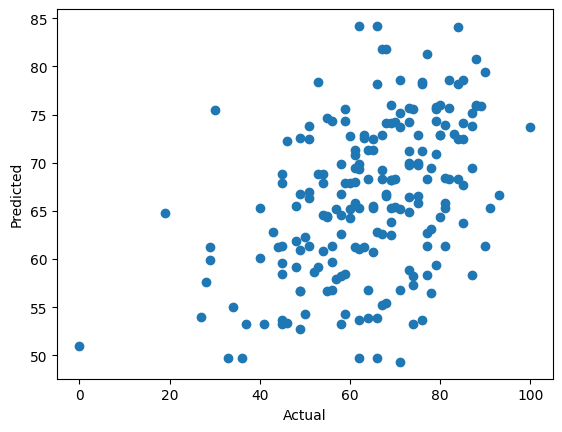

In [18]:
plt.scatter(y_test, y_pred);
plt.xlabel('Actual')
plt.ylabel('Predicted')

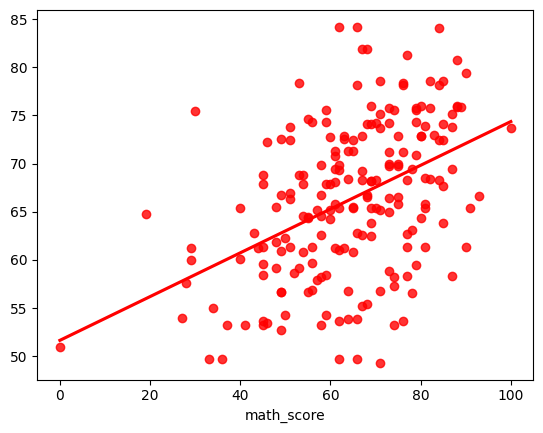

In [19]:
sns.regplot(x = y_test, y = y_pred, ci = None, color = 'red');

#### Difference between Actual and Predicted Values

In [20]:
pred_df = pd.DataFrame({'Actual Value' : y_test, 'Predicted Value' : y_pred, 'Difference' : y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,65.344269,25.655731
737,53,59.129273,-6.129273
740,80,75.993294,4.006706
660,74,58.195987,15.804013
411,84,84.069558,-0.069558
...,...,...,...
408,52,58.613524,-6.613524
332,62,84.214558,-22.214558
208,74,53.254762,20.745238
613,65,65.344269,-0.344269
